<a href="https://colab.research.google.com/github/DifferentiableUniverseInitiative/JaxPM/blob/main/docs/notebooks/01-Introduction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introduction to JaxPM

A minimal end-to-end example: build Gaussian initial conditions from a linear matter
power spectrum, displace particles with first-order LPT, evolve them with a Particle-Mesh step

In [1]:
# Install JaxPM. Runs only when the package is missing (e.g. on Colab);
# an existing local (editable) install is left untouched.
try:
    import jaxpm  # noqa: F401
except ImportError:
    %pip install -q --upgrade jax
    %pip install -q jaxpm

In [2]:
import jax
import jax.numpy as jnp
import jax_cosmo as jc
from jax.experimental.ode import odeint
from jaxpm.ode import make_ode_fn
from jaxpm.painting import paint
from jaxpm.pm import linear_field, lpt

In [3]:
mesh_shape = [128, 128, 128]
box_size = [128.0, 128.0, 128.0]
snapshots = jnp.array([0.1, 0.5, 1.0])


@jax.jit
def run_simulation(omega_c, sigma8):
    cosmo = jc.Planck15(Omega_c=omega_c, sigma8=sigma8)

    # Linear matter power spectrum -> Gaussian initial conditions.
    k = jnp.logspace(-4, 1, 128)
    pk = jc.power.linear_matter_power(cosmo, k)
    pk_fn = lambda x: jnp.interp(x, k, pk)

    # Create initial conditions and particles
    initial_conditions = linear_field(
        mesh_shape, box_size, pk_fn, seed=jax.random.PRNGKey(0)
    )
    particles = jnp.stack(jnp.meshgrid(*[jnp.arange(s) for s in mesh_shape]), axis=-1)

    # First-order LPT displacements from a uniform particle grid (particles=None
    dx, p, _ = lpt(cosmo, initial_conditions, particles, a=0.1, order=1)

    # Evolve the simulation forward
    sol = odeint(
        make_ode_fn(mesh_shape),
        [particles + dx, p],
        snapshots,
        cosmo,
        rtol=1e-8,
        atol=1e-8,
    )

    # sol = (displacements, momenta) sampled at each requested scale factor.
    return initial_conditions, (particles + dx), sol[0]

E0604 18:40:18.357502 3174649 numa_hwloc.cc:121] Call to hwloc_set_cpubind() failed: Invalid argument [22]
E0604 18:40:18.357520 3174650 numa_hwloc.cc:121] Call to hwloc_set_cpubind() failed: Invalid argument [22]
E0604 18:40:18.357606 3174651 numa_hwloc.cc:121] Call to hwloc_set_cpubind() failed: Invalid argument [22]


In [4]:
initial_conditions, lpt_dx, ode_dx = run_simulation(0.25, 0.8)

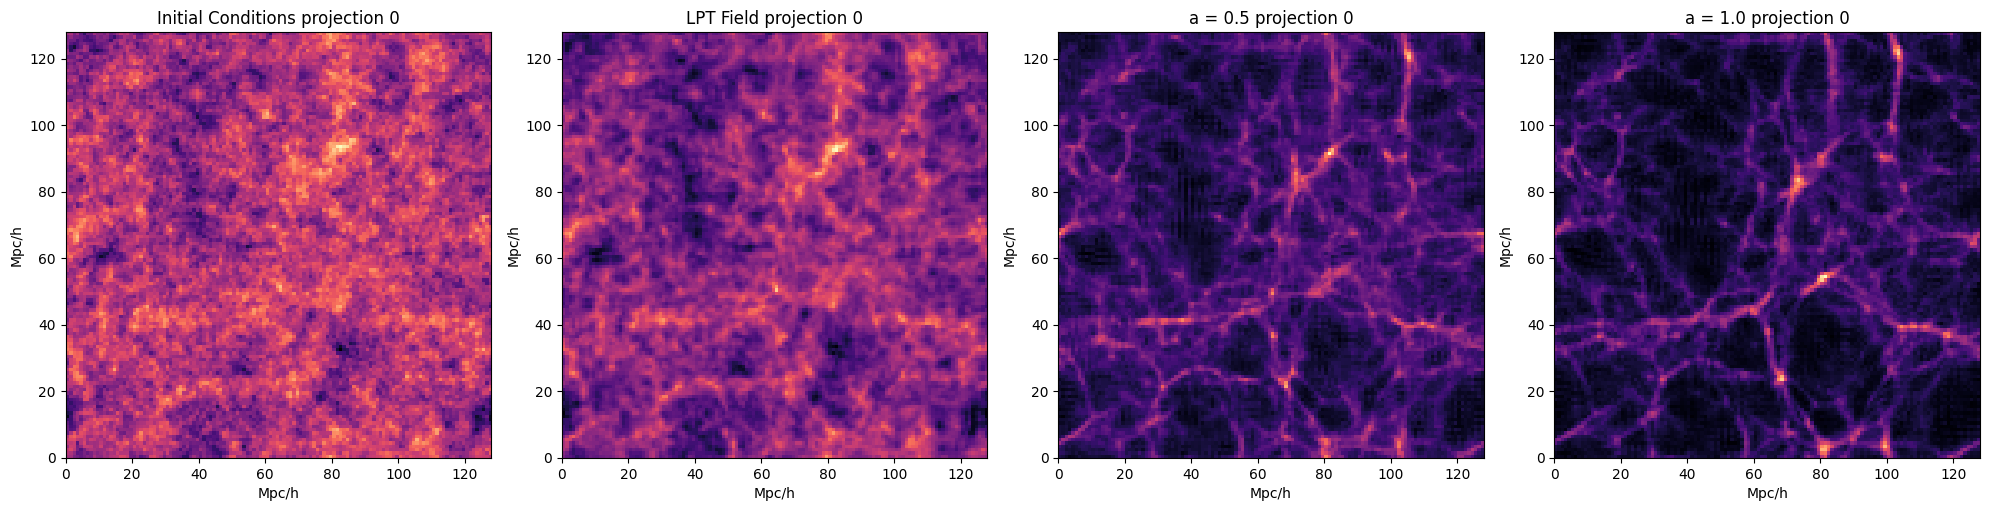

In [5]:
from jaxpm.plotting import plot_fields_single_projection

# The evolved state is a displacement field, so paint it with
# initial_particles='uniform' (a uniform grid is added internally).
density = lambda dx: jnp.log10(paint(dx, order="cic") + 1)

fields = {"Initial Conditions": initial_conditions, "LPT Field": density(lpt_dx)}
for a, dx_a in zip(snapshots[1:], ode_dx[1:]):
    fields[f"a = {float(a):.1f}"] = density(dx_a)
plot_fields_single_projection(fields)